train the model

🚀 开始训练 SAM-ViT-H Adapter, 共 50 轮...
【Epoch 1/50】 平均 Loss: 0.5177
【Epoch 2/50】 平均 Loss: 0.3376
【Epoch 3/50】 平均 Loss: 0.2832
【Epoch 4/50】 平均 Loss: 0.2627
【Epoch 5/50】 平均 Loss: 0.2527
【Epoch 6/50】 平均 Loss: 0.2458
【Epoch 7/50】 平均 Loss: 0.2403
【Epoch 8/50】 平均 Loss: 0.2367
【Epoch 9/50】 平均 Loss: 0.2324
【Epoch 10/50】 平均 Loss: 0.2279
【Epoch 11/50】 平均 Loss: 0.2251
【Epoch 12/50】 平均 Loss: 0.2241
【Epoch 13/50】 平均 Loss: 0.2227
【Epoch 14/50】 平均 Loss: 0.2189
【Epoch 15/50】 平均 Loss: 0.2170
【Epoch 16/50】 平均 Loss: 0.2158
【Epoch 17/50】 平均 Loss: 0.2141
【Epoch 18/50】 平均 Loss: 0.2133
【Epoch 19/50】 平均 Loss: 0.2111
【Epoch 20/50】 平均 Loss: 0.2135
【Epoch 21/50】 平均 Loss: 0.2091
【Epoch 22/50】 平均 Loss: 0.2075
【Epoch 23/50】 平均 Loss: 0.2064
【Epoch 24/50】 平均 Loss: 0.2082
【Epoch 25/50】 平均 Loss: 0.2056
【Epoch 26/50】 平均 Loss: 0.2035
【Epoch 27/50】 平均 Loss: 0.2051
【Epoch 28/50】 平均 Loss: 0.2023
【Epoch 29/50】 平均 Loss: 0.2011
【Epoch 30/50】 平均 Loss: 0.2004
【Epoch 31/50】 平均 Loss: 0.2005
【Epoch 32/50】 平均 Loss: 0.1986
【Epoch 33/50】

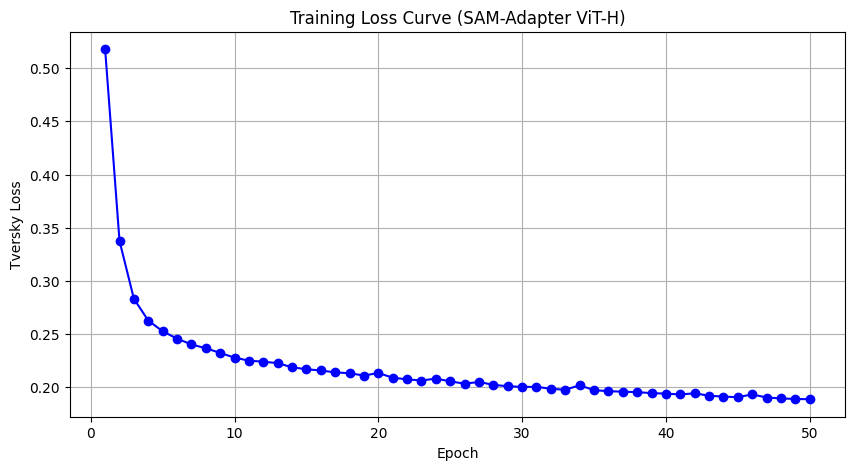

✅ 训练结束！
最强权重已存入: /gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_adapter_vith_best.pth
Loss 曲线已存入: sam_vith_loss_curve.png


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import os
import numpy as np
from torch.utils.data import DataLoader, Dataset
from segment_anything import sam_model_registry
import matplotlib.pyplot as plt


# 1. Adapter Core Module (Lightweight Bottleneck Structure)
class SamAdapter(nn.Module):
    def __init__(self, dim=256, adapter_dim=64):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Linear(dim, adapter_dim),
            nn.GELU(),
            nn.Linear(adapter_dim, dim)
        )
        # Initialize to zero to preserve pretrained features during early training
        nn.init.zeros_(self.adapter[-1].weight)
        nn.init.zeros_(self.adapter[-1].bias)

    def forward(self, x):
        return x + self.adapter(x)


# 2. SAM-ViT-H Wrapper Class (Dual Input Version)

class SAMwithAdapter(nn.Module):
    def __init__(self, model_type="vit_h", checkpoint=None):
        super().__init__()
        # Load the strongest ViT-H base model
        self.sam = sam_model_registry[model_type](checkpoint=checkpoint)
        # Freeze all SAM parameters, only train our added components
        for param in self.sam.parameters():
            param.requires_grad = False
            
        self.feature_dim = 256  # ViT-H Neck output remains 256
        self.adapter = SamAdapter(dim=self.feature_dim)
        
        # Prediction head: convert enhanced features to mask
        self.mask_head = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1)
        )

    def forward(self, image, diff_map):
        # Extract features from original and difference images
        feat_img = self.sam.image_encoder(image)
        with torch.no_grad():
            feat_diff = self.sam.image_encoder(diff_map)
        
        # Feature fusion: enhance hair signals, filter background
        features = feat_img + feat_diff 
        
        # Adjust feature flow through adapter
        b, c, h, w = features.shape
        x = self.adapter(features.permute(0, 2, 3, 1).reshape(b, h*w, c))
        features = x.reshape(b, h, w, c).permute(0, 3, 1, 2)
        
        # Output 1024x1024 prediction mask
        logits = self.mask_head(features)
        return torch.sigmoid(nn.functional.interpolate(logits, size=(1024, 1024), mode='bilinear'))


# 3. Loss Function (Tversky Loss for Fine Targets)

def tversky_loss(pred, target, alpha=0.3, beta=0.7):
    # Alpha and beta balance false positives and false negatives, aggressively capturing fine hairs
    num = (pred * target).sum()
    den = num + alpha * (pred * (1-target)).sum() + beta * ((1-pred) * target).sum()
    return 1 - (num + 1) / (den + 1)


# 4. Dataset Processing 

class HairDataset(Dataset):
    def __init__(self, img_dir, overlay_dir, mask_dir):
        self.img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.png')]
        self.overlay_dir = overlay_dir
        self.mask_dir = mask_dir
        self.kernel = np.ones((5,5), np.uint8)  # For slight GT dilation

    def __len__(self): 
        return len(self.img_paths)

    def __getitem__(self, idx):
        path = self.img_paths[idx]
        name = os.path.basename(path)
        
        # Read original and overlay images
        img = cv2.imread(path)
        ovl = cv2.imread(os.path.join(self.overlay_dir, name))
        diff = cv2.absdiff(img, ovl if ovl is not None else img)
        
        # Read mask
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)
        if mask is None:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        
        # Preprocessing function
        def prep(x, s=1024):
            x = cv2.resize(cv2.cvtColor(x, cv2.COLOR_BGR2RGB), (s,s))
            return torch.from_numpy(x).permute(2,0,1).float() / 255.0

        return prep(img), prep(diff), torch.from_numpy(cv2.resize(mask, (1024,1024))).unsqueeze(0).float() / 255.0


# 5. Main Training Loop 

def train():
    device = "cuda"
    # --- Weight saving paths ---
    SAVE_DIR = "/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam"
    FINAL_WEIGHT_PATH = os.path.join(SAVE_DIR, "sam_adapter_vith_best.pth")
    os.makedirs(SAVE_DIR, exist_ok=True)
    os.makedirs("train_vis", exist_ok=True) 

    # Load model
    model = SAMwithAdapter("vit_h", "/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_vit_h_4b8939.pth").to(device)
    optimizer = optim.Adam(list(model.adapter.parameters()) + list(model.mask_head.parameters()), lr=1e-4)
    
    loader = DataLoader(HairDataset(
        "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/dermoscopic_image", 
        "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/overlay", 
        "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/masks_hair"
    ), batch_size=1, shuffle=True)

    # --- Track per-epoch loss ---
    epoch_losses = [] 
    TOTAL_EPOCHS = 50  # Total training epochs

    print(f"Starting SAM-ViT-H Adapter training for {TOTAL_EPOCHS} epochs...")

    for epoch in range(TOTAL_EPOCHS):
        model.train()
        loss_sum = 0
        for batch_idx, (imgs, diffs, masks) in enumerate(loader):
            imgs, diffs, masks = imgs.to(device), diffs.to(device), masks.to(device)
            
            optimizer.zero_grad()
            out = model(imgs, diffs)
            loss = tversky_loss(out, masks)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            
            # Save visualization every 100 steps
            if batch_idx % 100 == 0:
                vis_img = (out[0,0].detach().cpu().numpy() * 255).astype(np.uint8)
                cv2.imwrite(f"train_vis/epoch_{epoch+1}_step_{batch_idx}.png", vis_img)

        # Calculate and save average loss for this epoch
        avg_loss = loss_sum / len(loader)
        epoch_losses.append(avg_loss)
        
        print(f"Epoch {epoch+1}/{TOTAL_EPOCHS} - Average Loss: {avg_loss:.4f}")
        
        # Save latest weights
        torch.save(model.state_dict(), FINAL_WEIGHT_PATH)

    # --- Save loss curve after training ---
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, TOTAL_EPOCHS + 1), epoch_losses, marker='o', color='b')
    plt.title('Training Loss Curve (SAM-Adapter ViT-H)')
    plt.xlabel('Epoch')
    plt.ylabel('Tversky Loss')
    plt.grid(True)
    plt.savefig('sam_vith_loss_curve.png')
    plt.show()
    
    print(f"Training completed!")
    print(f"Weights saved to: {FINAL_WEIGHT_PATH}")
    print(f"Loss curve saved to: sam_vith_loss_curve.png")

if __name__ == "__main__":
    train()

Performing hair segmentation inference on a single image using a pre-trained SAM-ViT-H model

In [5]:
import torch, cv2, numpy as np
device = "cuda"
model = SAMwithAdapter("vit_h", "/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_vit_h_4b8939.pth").to(device)
model.load_state_dict(torch.load("/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_adapter_vith_best.pth"))
model.eval()

img = cv2.imread("/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/dermoscopic_image/ISIC_0000042.png")
ovl = cv2.imread("/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/overlay/ISIC_0000042.png")
diff = cv2.absdiff(img, ovl)

def prep(x): return torch.from_numpy(cv2.resize(cv2.cvtColor(x, cv2.COLOR_BGR2RGB), (1024,1024))).permute(2,0,1).float().unsqueeze(0).to(device)/255.
with torch.no_grad():
    mask = (model(prep(img), prep(diff)).squeeze().cpu().numpy()*255).astype(np.uint8)

res = cv2.resize(img, (1024,1024)); red = np.zeros_like(res); red[:,:,2] = mask
cv2.imwrite("vis_vith_result.png", cv2.addWeighted(res, 0.7, red, 0.3, 0))

True

In [ ]:
import torch
import cv2
import os
import numpy as np

def batch_inference():
    device = "cuda"
    # 1. Load model
    model = SAMwithAdapter("vit_h", "/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_vit_h_4b8939.pth").to(device)
    model.load_state_dict(torch.load("/gpfs/work/bio/yixuanli2204/FYP_Project/weights/sam/sam_adapter_vith_best.pth"))
    model.eval()

    # 2. Path configuration
    img_dir = "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/dermoscopic_image"
    overlay_dir = "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/overlay"
    output_dir = "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/sam_predicted_masks"
    os.makedirs(output_dir, exist_ok=True)

    print("Starting batch generation of 500 hair masks...")
    
    with torch.no_grad():
        for filename in os.listdir(img_dir):
            if not filename.endswith(".png"): 
                continue
            
            # Read original image and overlay
            img = cv2.imread(os.path.join(img_dir, filename))
            overlay = cv2.imread(os.path.join(overlay_dir, filename))
            diff = cv2.absdiff(img, overlay)
            
            # Preprocessing
            img_t = torch.from_numpy(cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (1024, 1024))).permute(2,0,1).float().unsqueeze(0).to(device) / 255.0
            diff_t = torch.from_numpy(cv2.resize(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB), (1024, 1024))).permute(2,0,1).float().unsqueeze(0).to(device) / 255.0

            # Prediction
            pred = model(img_t, diff_t)
            mask_np = (pred.squeeze().cpu().numpy() * 255).astype(np.uint8)
            
            # Binarization: clean up the mask
            _, mask_binary = cv2.threshold(mask_np, 127, 255, cv2.THRESH_BINARY)
            
            # Save
            cv2.imwrite(os.path.join(output_dir, filename), mask_binary)

    print(f"Completed! Masks saved to: {output_dir}")

if __name__ == "__main__":
    batch_inference()